### Gini

Gini Index:
$$Gini(S) = 1 - \sum_{i=1}^{c} (p_i)^2$$

General Gini:
$$Gini_{split} = \frac{|S_{left}|}{|S|} Gini(S_{left}) + \frac{|S_{right}|}{|S|} Gini(S_{right})$$

$Gini = 1 - ((6/8)^2 + (2/8)^2) = 0.375$

$Gini = 1 - ((3/6)^2 + (3/6)^2) = 0.5$

$$Gini_{Wind} = \frac{8}{14} \cdot 0.375 + \frac{6}{14} \cdot 0.5 \approx \mathbf{0.428}$$

$$Gini_{Outlook} = \left( \frac{5}{14} \cdot 0.48 \right) + \left( \frac{4}{14} \cdot 0 \right) + \left( \frac{5}{14} \cdot 0.48 \right)\approx \mathbf{0.3428}$$


<font color = green >

# Decision Trees
</font>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%matplotlib inline 

<font color = green >

## Iris dataset 
</font>

In [3]:
# Don't install graphviz with the help of pip, use conda install  graphviz
# !pip install graphviz

In [4]:
# !conda install graphviz

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz
from sklearn.model_selection import train_test_split
# Note: In case of RuntimeError "Make sure the Graphviz executables are on your system's path” after installing Graphviz 
# helps on mac:  brew install graphviz
# helps on windows:  import os
# os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz2.38\bin'

In [6]:
iris= load_iris()

iris = load_iris()
X, y, features, labels = iris.data, iris.target,iris.feature_names ,iris.target_names

print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)
print ('features:', features)
dict_names = {i:v for i,v in enumerate(labels)}
print ('target names :', dict_names)

X.shape=  (150, 4)
y.shape=  (150,)
X_train.shape=  (112, 4)
X_test.shape=  (38, 4)
y_train.shape=  (112,)
y_test.shape=  (38,)
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names : {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


<font color = green >

## Learning the model
</font>

In [7]:
max_depth = 3
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,        
    max_depth=max_depth,    
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 98.214%
test accuracy= 97.368%


In [8]:
max_depth = 2
clf = DecisionTreeClassifier(
    criterion=  'gini',
    random_state=20,        
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 94.737%


<font color = green >

## Vizualize the decision tree  graph 
</font>

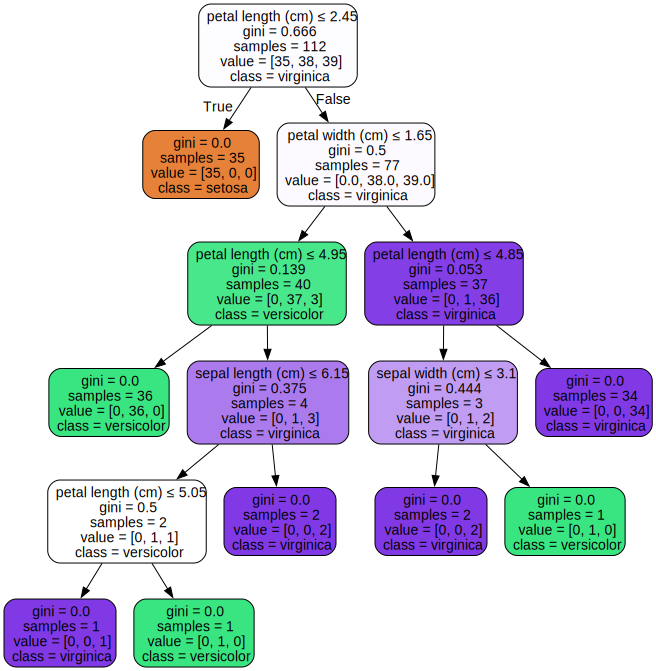

In [9]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=features,  
                                class_names=labels,  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

display(graph)

<font color = green >

## Feature importance
</font>

In [10]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(6, 6), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)

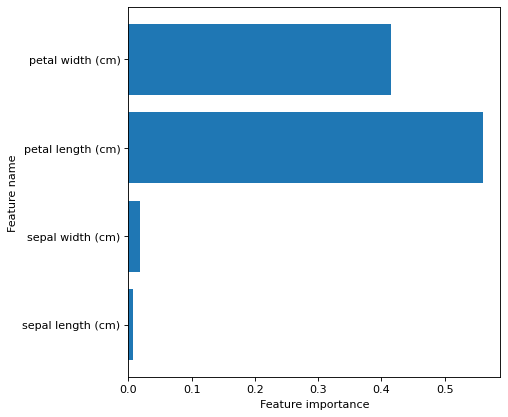

In [11]:
plot_feature_importances(clf, features)

<font color = green >

## Regressor
</font>

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [13]:
X, y = make_regression(n_samples=500, n_features=5, noise=0.2, random_state=42)
features = ['Size', 'Year', 'Rooms', 'Location', 'Condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [14]:
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=10).fit(X_train, y_train)

In [15]:
print(f"Train R² Score: {reg_tree.score(X_train, y_train):.3%}")
print(f"Test R² Score:  {reg_tree.score(X_test, y_test):.3%}")

Train R² Score: 71.579%
Test R² Score:  69.929%


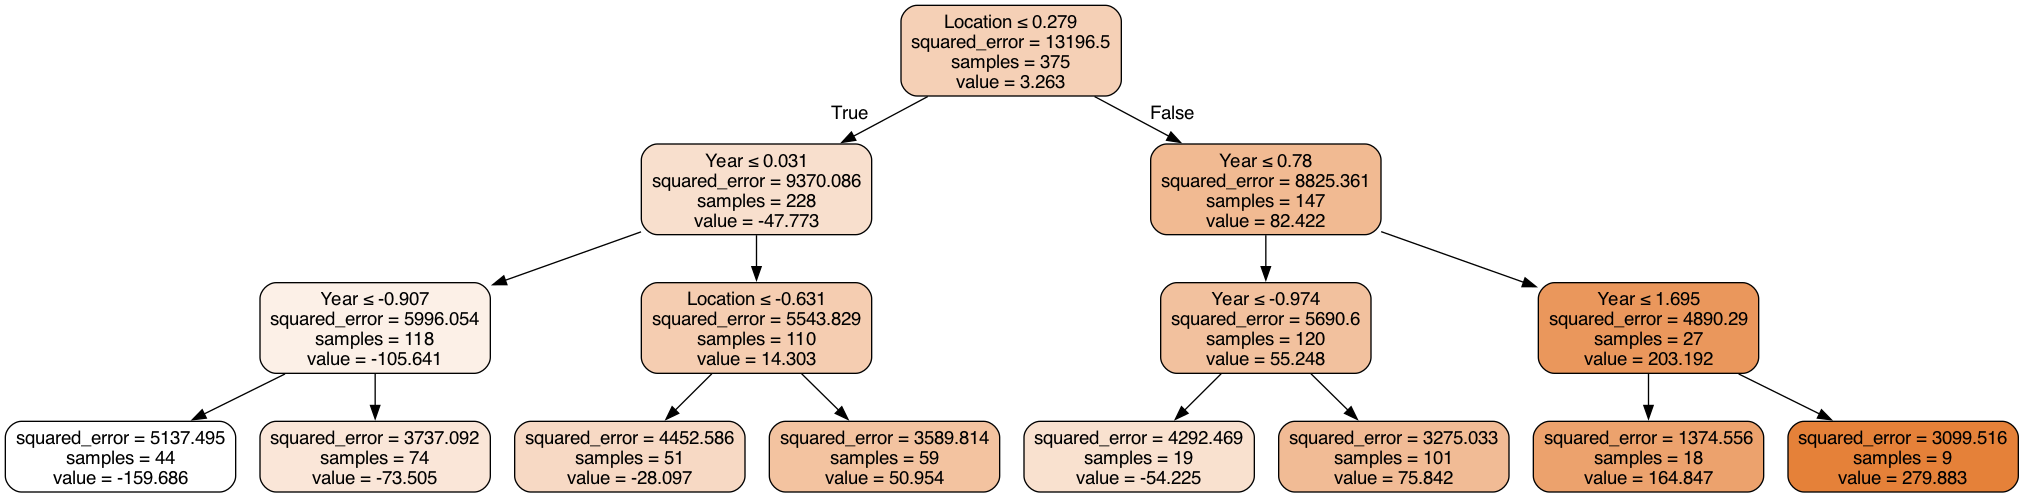

In [16]:
from IPython.display import Image

dot_data = tree.export_graphviz(reg_tree, out_file=None, 
                                feature_names=features,  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

Image(graph.pipe(format='png'), width=1900, height=1000)

In [17]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(8, 5), dpi=80)
    n_features = len(features)
    plt.barh(range(n_features), clf.feature_importances_, color='lightgreen', edgecolor='black')
    plt.xlabel("Feature Importance (Contribution to Variance Reduction)")
    plt.ylabel("Feature Name")
    plt.yticks(np.arange(n_features), features)
    plt.title("Decision Tree Regression: Feature Importances")
    plt.show()

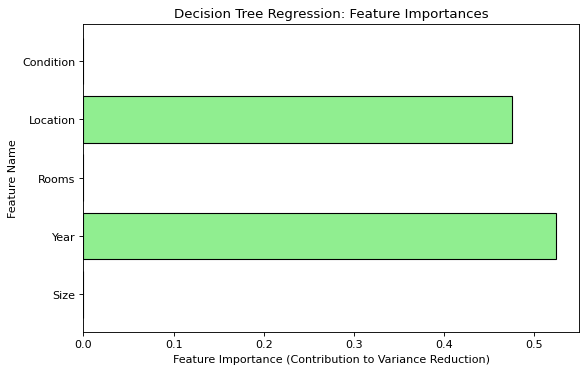

In [18]:
plot_feature_importances(reg_tree, features)

<font color = green >

## Auxiliary drawing functions 
</font>

In [19]:
def plot_decision_boundary(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.05,plot_symbol_size = 50, ax= None,  is_extended=True, title_size= None):

    '''    
    Draws the binary decision boundary for X that is nor required additional features and transformation (like polynomial)
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_points = np.array(['grey', 'orange']) # neg/pos
    colors_for_areas = np.array(['grey', 'orange']) # neg/pos  # alpha is applied later 
    cmap_light = ListedColormap(colors_for_areas)
 
   
    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples 
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])

    print ('Call prediction for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape 
    Z = Z.reshape(xx1.shape)
    
    if ax:
        plt.sca(ax)
    
    # Plot all meshgrid prediction      
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size, 
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size, 
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        # Create legend  
        import matplotlib.patches as mpatches # use to assign lavels for colored points 
        patch0 = mpatches.Patch(color=colors_for_points[0], label='negative')
        patch1 = mpatches.Patch(color=colors_for_points[1], label='positive')
        plt.legend(handles=[patch0, patch1])
    
    fontdict={'fontsize': title_size} if title_size else None
    
    plt.title(title, fontdict)
    if is_extended:
        plt.xlabel('feature 1')
        plt.ylabel('feature 2')
    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False, 
        labelbottom = False
        )

        
    
def plot_data_logistic_regression(X,y,legend_loc= None, title= None):
    '''
    :param X: 2 dimensional ndarray
    :param y:  1 dimensional ndarray. Use y.ravel() if necessary
    :return:
    '''

    positive_indices = (y == 1)
    negative_indices = (y == 0)
#     import matplotlib as mpl
    colors_for_points = ['grey', 'orange'] # neg/pos

    plt.scatter(X[negative_indices][:,0], X[negative_indices][:,1], s=40, c=colors_for_points [0], edgecolor = 'black', label='negative', alpha = 0.7)
    plt.scatter(X[positive_indices][:,0], X[positive_indices][:,1], s=40, c=colors_for_points [1], edgecolor = 'black',label='positive', alpha = 0.7)
    plt.title(title)
    plt.legend(loc= legend_loc)

    
def plot_multi_class_logistic_regression(X,y,dict_names=None, colors= None,  title =None):
    '''
    Draw the multi class samples of 2 features
    :param X: X 2 ndarray (m,2),
    :param y: vector (m,)
    :param dict_names: dict of values of y and names
    :return: None
    '''
    if not colors:
        colors_for_points = ['green','grey', 'orange', 'brown']
    else:
         colors_for_points = colors

    y_unique = list(set(y))

    for i in range (len(y_unique)):
        ind = y == y_unique[i] # vector

        if dict_names:
            plt.scatter(X[ind,0], X[ind,1], c=colors_for_points[i], s=40, label=dict_names[y_unique[i]],edgecolor='black', alpha=.7)
        else:
            plt.scatter(X[ind, 0], X[ind, 1], s=40, c=colors_for_points [i], edgecolor = 'black', alpha = 0.7)
    if title:
        plt.title(title)

    if dict_names:
        plt.legend(frameon=True)
        


<font color = green >

## Synthetic dataset
</font>

In [20]:
from sklearn.datasets import make_blobs

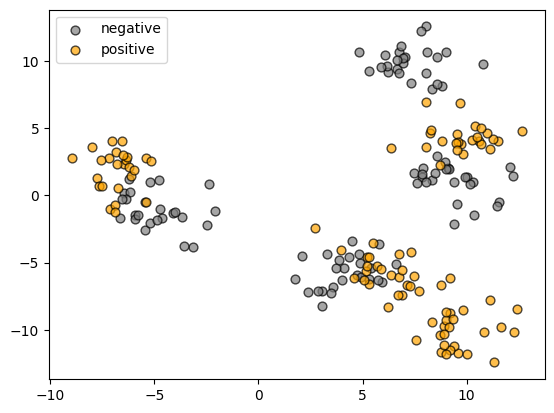

In [21]:
X_mk8, y_mk8 = make_blobs(n_samples = 200, n_features = 2, centers = 8, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
X_train = X_mk8
y_train = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]
plt.figure()
plot_data_logistic_regression(X_mk8,y_train)


Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)
Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)
Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)


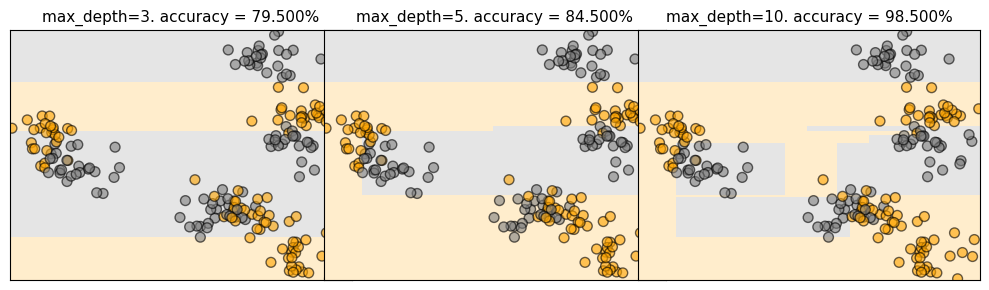

In [22]:
plt.figure(figsize= (10,3))
max_depths= [3,5,10]    

for i, max_depth in enumerate(max_depths):
    ax = plt.subplot(1,len(max_depths),i+1)
    clf = DecisionTreeClassifier(
        criterion=  'entropy',
        random_state=20,        
        max_depth=max_depth,    
    #     max_leaf_nodes=4,
    ).fit(X_train, y_train)
    accuracy = clf.score (X_train, y_train)
#     print("train accuracy= {:.3%}".format(accuracy))
    plot_decision_boundary(
        clf,
        X_train,
        y_train,
        precision= 0.05,
        ax=ax,
        title = 'max_depth={}. accuracy = {:.3%}'.format(max_depth, accuracy),
        is_extended= False,
        title_size= 11,)
    
plt.tight_layout (w_pad=-2)


# max_depth=5    
# clf = DecisionTreeClassifier(
#     criterion=  'entropy',
#     random_state=20,        
#     max_depth=max_depth,    
# #     max_leaf_nodes=4,
# ).fit(X_train, y_train)
# accuracy = clf.score (X_train, y_train)
# print("train accuracy= {:.3%}".format(accuracy))
# plt.figure()

# plot_decision_boundary(clf, X_train, y_train, precision= 0.05, title = 'max_depth={}. accuracy = {:.3%}'.format(max_depth, accuracy))

In [23]:
# graph_viz = tree.export_graphviz(clf, out_file=None,filled = True)
# graph = graphviz.Source(graph_viz)
# graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

#### Should appear the followingf image in separate window 

<img src = "data/decision_tree_graph2.jpg" height=500 width= 500 align="left">

<div style="clear:left;"></div>
<br><br><br><br><br><br><br><br>


<font color = green >

## Tennis dataset

</font>

In [24]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'tennis.csv')
fn=  'data/tennis.csv'
df = pd.read_csv(fn)
del df['temp']
print (df.head())

X_train = df.iloc[:, :3].values
y_train = df.iloc[:, 3].values
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)

    outlook humidity   wind play
0     sunny     high  False   no
1     sunny     high   True   no
2  overcast     high  False  yes
3     rainy     high  False  yes
4     rainy   normal  False  yes

X_train.shape=  (14, 3)
y_train.shape=  (14,)


In [25]:
from sklearn.preprocessing  import LabelEncoder

In [26]:
X_train_cat = X_train.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print ('{}: {}'.format(list(df)[i], le_dict))
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

outlook: {'overcast': np.int64(0), 'rainy': np.int64(1), 'sunny': np.int64(2)}
humidity: {'high': np.int64(0), 'normal': np.int64(1)}
wind: {False: np.int64(0), True: np.int64(1)}
y:  {'no': np.int64(0), 'yes': np.int64(1)}
X_train_cat.shape=  (14, 3)
y_train_cat.shape=  (14,)


array([[2, 0, 0],
       [2, 0, 1],
       [0, 0, 0],
       [1, 0, 0],
       [1, 1, 0],
       [1, 1, 1],
       [0, 1, 1],
       [2, 0, 0],
       [2, 1, 0],
       [1, 1, 0],
       [2, 1, 1],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 1]], dtype=object)

In [27]:
max_depth = None
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,        
    max_depth=max_depth,    
    # max_leaf_nodes=4,
).fit(X_train_cat, y_train_cat)
features = list(df)[:3]
labels = ['No','Yes']

print("train accuracy= {:.3%}".format(clf.score (X_train_cat, y_train_cat)))

train accuracy= 100.000%


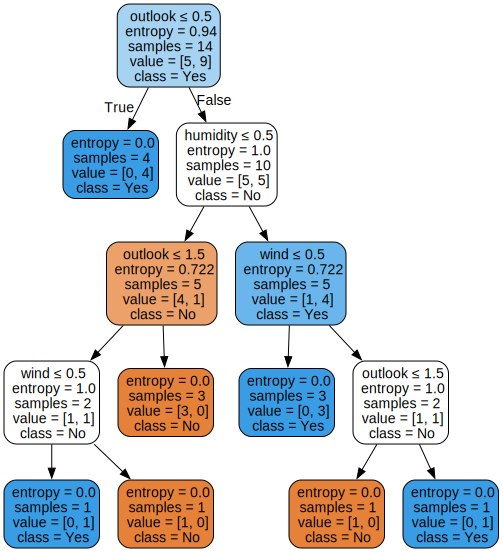

In [28]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=list(features),  
                                class_names=[str(l) for l in labels],  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

display(graph)

<font color = green>

#  Random Forests

</font>



In [29]:
from sklearn.ensemble import RandomForestClassifier

<font color = green>

## Iris dataset

</font>



In [30]:
iris = load_iris()
X, y, features, labels = iris.data, iris.target,iris.feature_names ,iris.target_names

print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)
print ('features:', features)
dict_names = {i:v for i,v in enumerate(labels)}
print ('target names :', dict_names)

X.shape=  (150, 4)
y.shape=  (150,)
X_train.shape=  (112, 4)
X_test.shape=  (38, 4)
y_train.shape=  (112,)
y_test.shape=  (38,)
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names : {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


In [31]:
clf = RandomForestClassifier().fit (X_train, y_train)
clf.score (X_train, y_train)
n_estimators_list= [5,10,20]
max_features_list= list(np.arange(1, X_train.shape[1]+1))

for i in range (len(n_estimators_list)): 
    for j in range (len(max_features_list)):
        index = len(max_features_list)*i+j           
        clf = RandomForestClassifier(
            random_state=10,
            n_estimators= n_estimators_list[i],
            max_features=max_features_list[j],        
        ).fit(X_train, y_train)
        accuracy_train = clf.score (X_train, y_train)
        accuracy_test = clf.score (X_test, y_test)
        print ('n_estimators= {}, max_features = {}, accuracy_train = {:.3%}, accuracy_test = {:.3%}'.format (
            n_estimators_list[i],max_features_list[j], accuracy_train, accuracy_test))

n_estimators= 5, max_features = 1, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 2, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 3, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 4, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 10, max_features = 1, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 10, max_features = 2, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 10, max_features = 3, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 10, max_features = 4, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 20, max_features = 1, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 20, max_features = 2, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 20, max_features = 3, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 20, max_features = 4, accuracy_train 

In [32]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test, y_test)))

--- RANDOM FOREST RESULTS (ENSEMBLE) ---
Train accuracy (RF) = 97.321%
Test accuracy (RF) = 97.368%

--- DECISION TREE RESULTS (SINGLE TREE) ---
Train accuracy (DT) = 98.214%
Test accuracy (DT) = 97.368%


In [33]:
# Conclusion: this dataset is not good to demonstrate the power of random forest 

<font color = green>

## Mushrooms dataset

</font>



In [34]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'mushrooms.csv')
fn= 'data/mushrooms.csv'
# https://www.kaggle.com/ymotonskillupai/mushroomscsv
df = pd.read_csv(fn)

print (list(df))
X = df.iloc[:, 1:].values
y = df.iloc[:, 1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)
df.head()

['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

X_train.shape=  (6093, 22)
y_train.shape=  (6093,)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [35]:
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print (X_test[:,i])
    X_test_cat[:,i] = le.transform(X_test[:,i])
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
y_test_cat= le.transform(y_test)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

['x' 'f' 'x' ... 'x' 'x' 'k']
['y' 'y' 'y' ... 'y' 's' 's']
['n' 'g' 'y' ... 'e' 'y' 'n']
['t' 't' 't' ... 'f' 't' 'f']
['p' 'n' 'a' ... 's' 'l' 'n']
['f' 'f' 'f' ... 'f' 'f' 'a']
['c' 'c' 'c' ... 'c' 'c' 'c']
['n' 'b' 'b' ... 'n' 'b' 'b']
['p' 'p' 'k' ... 'b' 'k' 'y']
['e' 't' 'e' ... 't' 'e' 'e']
['e' 'b' 'c' ... '?' 'c' '?']
['s' 's' 's' ... 's' 's' 's']
['s' 's' 's' ... 'k' 's' 's']
['w' 'g' 'w' ... 'p' 'w' 'o']
['w' 'g' 'w' ... 'p' 'w' 'o']
['p' 'p' 'p' ... 'p' 'p' 'p']
['w' 'w' 'w' ... 'w' 'w' 'n']
['o' 'o' 'o' ... 'o' 'o' 'o']
['p' 'p' 'p' ... 'e' 'p' 'p']
['k' 'k' 'n' ... 'w' 'k' 'b']
['s' 'y' 'n' ... 'v' 's' 'c']
['u' 'd' 'm' ... 'd' 'g' 'l']
y:  {'b': np.int64(0), 'c': np.int64(1), 'f': np.int64(2), 'k': np.int64(3), 's': np.int64(4), 'x': np.int64(5)}
X_train_cat.shape=  (6093, 22)
y_train_cat.shape=  (6093,)


array([[2, 3, 9, ..., 1, 5, 1],
       [5, 3, 4, ..., 3, 5, 1],
       [2, 2, 3, ..., 2, 0, 1],
       ...,
       [5, 2, 3, ..., 3, 3, 1],
       [2, 0, 4, ..., 3, 4, 0],
       [5, 3, 3, ..., 3, 5, 0]], shape=(6093, 22), dtype=object)

In [36]:
max_features_list = [20,12, 10,8,6,4,3,2,1]    
for i, max_features in enumerate(max_features_list):
    clf = RandomForestClassifier(
        random_state=0,        
        max_features= max_features,    
    ).fit(X_train_cat, y_train_cat)
    accuracy_train = clf.score(X_train_cat, y_train_cat)
    accuracy_test = clf.score(X_test_cat, y_test_cat)
    print ('max_features = {}:\n\t accuracy_train = {:.3%}\n\t accuracy_test = {:.3%}'.format (
        max_features_list[i], accuracy_train, accuracy_test))

max_features = 20:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 12:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 10:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 8:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 6:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 4:
	 accuracy_train = 100.000%
	 accuracy_test = 99.951%
max_features = 3:
	 accuracy_train = 100.000%
	 accuracy_test = 99.803%
max_features = 2:
	 accuracy_train = 100.000%
	 accuracy_test = 99.606%
max_features = 1:
	 accuracy_train = 100.000%
	 accuracy_test = 99.409%


In [37]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth,
).fit(X_train_cat, y_train_cat)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train_cat, y_train_cat)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test_cat, y_test_cat)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train_cat, y_train_cat)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train_cat, y_train_cat)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test_cat, y_test_cat)))

--- RANDOM FOREST RESULTS (ENSEMBLE) ---
Train accuracy (RF) = 94.371%
Test accuracy (RF) = 93.550%

--- DECISION TREE RESULTS (SINGLE TREE) ---
Train accuracy (DT) = 99.951%
Test accuracy (DT) = 99.951%


In [38]:
# Conclusion: this dataset is also  not good to demonstrate the power of random forest :)

<font color = green >

# Gradient boosting decision tree
</font>

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

<font color = green>

## Fruits dataset 2D

</font>



In [40]:
import os
cwd= os.getcwd() 
path = os.path.join(cwd,'data')
fn=  os.path.join(path , 'fruit_data_with_colors.txt')
df_fruits = pd.read_table(fn)
df_fruits.head(10)


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81
7,2,mandarin,mandarin,76,5.8,4.0,0.81
8,1,apple,braeburn,178,7.1,7.8,0.92
9,1,apple,braeburn,172,7.4,7.0,0.89


In [41]:
def plot_decision_boundary_universal(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.1,plot_symbol_size = 50, ax= None,  is_extended=True, labels= None, features =None):
    '''
    expected to be universal for binary and multiclass classification but not tested for binary 
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_areas= colors_for_points =  np.array(['green','grey', 'orange', 'brown'])
    cmap_light = ListedColormap(colors_for_areas)

    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])
    if precision<0.05:
        print ('Calling to predict for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape
    Z = Z.reshape(xx1.shape)

    if ax:
        plt.sca(ax)

    # Plot all meshgrid prediction
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size,
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size,
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        
        # Create legend
        if labels is None:
            labels= ['negative','positive'] # assume this is for binary or for muticlass with labels 
        import matplotlib.patches as mpatches # use to assign lavels for colored points
        patches= [mpatches.Patch(color=colors_for_points[i], label=labels[i]) for i in range (len(labels))]
        plt.legend(handles=patches)
        if features is None:
            plt.xlabel('feature 1')
            plt.ylabel('feature 2')
        else: 
            plt.xlabel(features[0])
            plt.ylabel(features[1])

    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False,
        labelbottom = False
        )
    plt.title(title)


X_train.shape=  (44, 2)
X_test.shape=  (15, 2)
y_train.shape=  (44,)
y_test.shape=  (15,)
target names : {np.int64(0): 'apple', np.int64(1): 'mandarin', np.int64(2): 'orange', np.int64(3): 'lemon'}


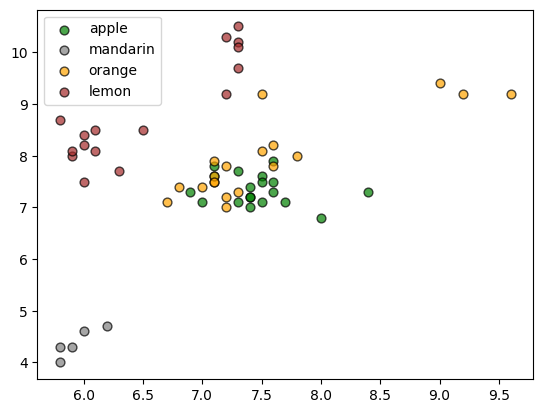

In [42]:
features = ['width', 'height']
X = df_fruits[features].values
y = df_fruits['fruit_label'].values -1  # shift due to labels of fruits are from 1 

df_fruits.head(20)
# labels =  df_fruits['fruit_name'].unique()
fruits_dict = dict(zip(np.unique(y), df_fruits['fruit_name'].unique()))

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)

print ('target names :', fruits_dict)

plt.figure()
plot_multi_class_logistic_regression (X,y,dict_names=fruits_dict)


train accuracy= 95.455%
test accuracy= 80.000%


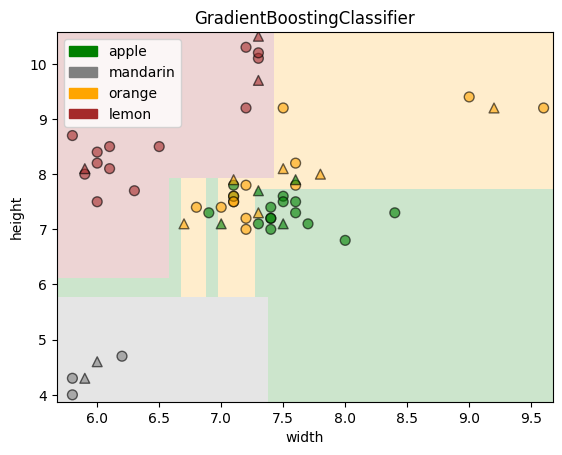

In [43]:
plt.figure ()
labels =list(fruits_dict.values())

clf = GradientBoostingClassifier(learning_rate=0.01,max_depth=3).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
plot_decision_boundary_universal(clf, X_train, y_train, X_test, y_test, title='GradientBoostingClassifier', precision=0.05, labels= labels, features = features)


---

<font color = green>

##  XGBoost
</font>



In [44]:
!pip install XGBoost

zsh:1: command not found: pip


In [45]:
from xgboost import XGBClassifier

clf_xgboost = XGBClassifier(use_label_encoder=False, eval_metric= 'logloss')
clf_xgboost.fit(X_train, y_train)
print('\nAccuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf_xgboost.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf_xgboost.score(X_test, y_test)))



/Users/macbook/code/Amazinum_HW/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:20:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy of Logistic regression classifier on training set: 0.98
Accuracy of Logistic regression classifier on test set: 0.60


In [46]:
#help(XGBClassifier)

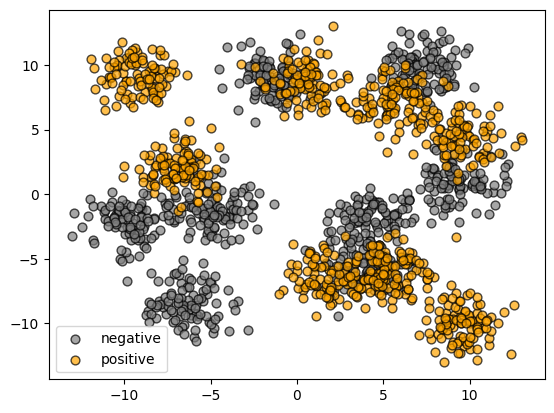

In [47]:
X_mk8, y_mk8 = make_blobs(n_samples = 2000, n_features = 2, centers = 16, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
X = X_mk8
y = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
plt.figure()
plot_data_logistic_regression(X_train,y_train)

In [48]:
print(X_train.shape)
y_train.shape

(1500, 2)


(1500,)

In [49]:
X_train

array([[ -7.11271763,  -2.18572036],
       [  9.04587707, -11.46625813],
       [ -4.37859762,   1.69193429],
       ...,
       [  5.26290094,  -5.6390031 ],
       [  1.0183784 ,  -6.95986805],
       [ -6.21752906,  -0.20391296]], shape=(1500, 2))

In [50]:
common_max_depth = 3
seed = 10

print('='*30)
print('DECISION TREE')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=seed,        
    max_depth=common_max_depth
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_dt.score(X_test, y_test)))

print('\n' + '='*30)
print('RANDOM FOREST')
clf_rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n' + '='*30)
print('GRADIENT BOOSTING')
clf_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_gb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_gb.score(X_test, y_test)))

print('\n' + '='*30)
print('XGBOOST')
clf_xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss',
    n_estimators=100,
    max_depth=common_max_depth, 
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_xgb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_xgb.score(X_test, y_test)))

DECISION TREE
Train accuracy = 82.267%
Test accuracy  = 78.400%

RANDOM FOREST
Train accuracy = 85.800%
Test accuracy  = 80.200%

GRADIENT BOOSTING
Train accuracy = 91.667%
Test accuracy  = 83.000%

XGBOOST
Train accuracy = 93.000%
Test accuracy  = 83.400%


/Users/macbook/code/Amazinum_HW/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:20:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<font color = green >
    
# Home Task 

</font>



<font color = green>

##  Brest cancer  dataset
</font>



In [51]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


<font color = green>

##  DecisionTree 

</font>



In [52]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from numpy.random import RandomState
seed = RandomState(0)

clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=seed,        
    max_depth=3
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf_dt.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf_dt.score (X_test, y_test)))
graph_viz = tree.export_graphviz(clf_dt, out_file=None,feature_names=features, class_names=labels, filled = True)
graph = graphviz.Source(graph_viz)
graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

train accuracy= 97.653%
test accuracy= 95.105%


'Source.gv.pdf'

In [53]:
def plot_feature_importances(clf, features, figure_size=(8, 6), dpi=200):
    plt.figure(figsize=figure_size, dpi=dpi)
    n_features = len(features)
    plt.barh(range(n_features), clf.feature_importances_)
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.yticks(np.arange(n_features), features)
    plt.title(f"{clf.__class__.__name__} : Feature Importances")
    plt.show()


In [54]:
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score, accuracy_score

def evaluate_classifier(clf, X_train, y_train, X_test, y_test) -> pd.DataFrame:
    
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    metrics = {
        'accuracy': (accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)),
        'precision': (precision_score(y_train, y_train_pred), precision_score(y_test, y_test_pred)),
        'recall': (recall_score(y_train, y_train_pred), recall_score(y_test, y_test_pred)),
        'f1_score': (f1_score(y_train, y_train_pred), f1_score(y_test, y_test_pred)),
        'roc_auc': (roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1]), roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))
    }
    
    display(pd.DataFrame(metrics, index=['train', 'test']))


Best parameters found:  {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__max_leaf_nodes': 5}


,accuracy,precision,recall,f1_score,roc_auc
train,0.960094,0.969925,0.966292,0.968105,0.979601
test,0.958042,1.000000,0.933333,0.965517,0.992243


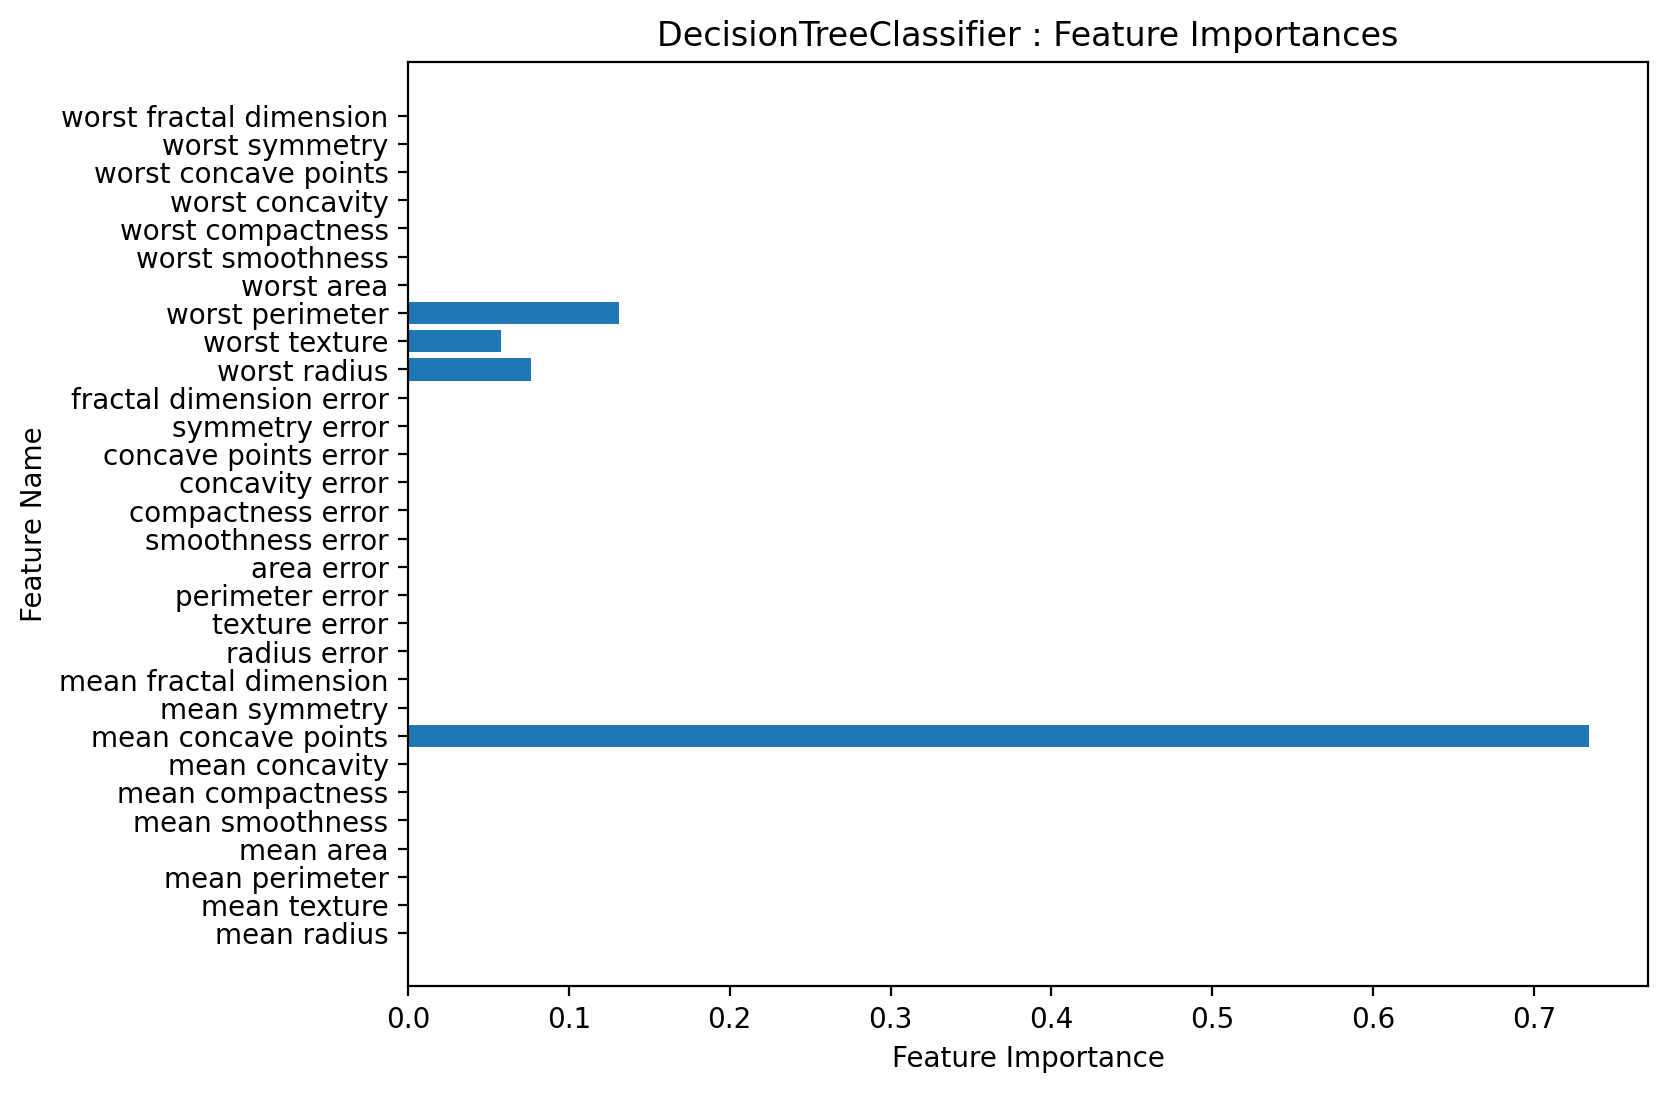

In [55]:
#pipeline and grid search for decision tree
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

decision_tree = GridSearchCV(
    estimator= Pipeline(
    [
        ('scaler', StandardScaler()), 
        ('model', DecisionTreeClassifier(random_state=seed))
    ]
    ),
    param_grid={
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': [None, 2, 3, 4, 5],
        'model__max_leaf_nodes': [None, 2, 3, 4, 5]
    },
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True, # refit the best model on the whole dataset after finding the best parameters
).fit(X_train, y_train)
print('Best parameters found: ', decision_tree.best_params_)
evaluation_results = evaluate_classifier(decision_tree, X_train, y_train, X_test, y_test)
plot_feature_importances(decision_tree.best_estimator_.named_steps['model'],
                         features) 

<font color = green>

##  RandomForest

</font>



In [56]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
clf = RandomForestClassifier(
    criterion='entropy',
    random_state=seed,        
    max_depth=3
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 98.122%
test accuracy= 96.503%


Best parameters found:  {'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_leaf_nodes': 5, 'model__n_estimators': 10}


,accuracy,precision,recall,f1_score,roc_auc
train,0.974178,0.977612,0.981273,0.979439,0.994347
test,0.951049,0.966292,0.955556,0.960894,0.993501


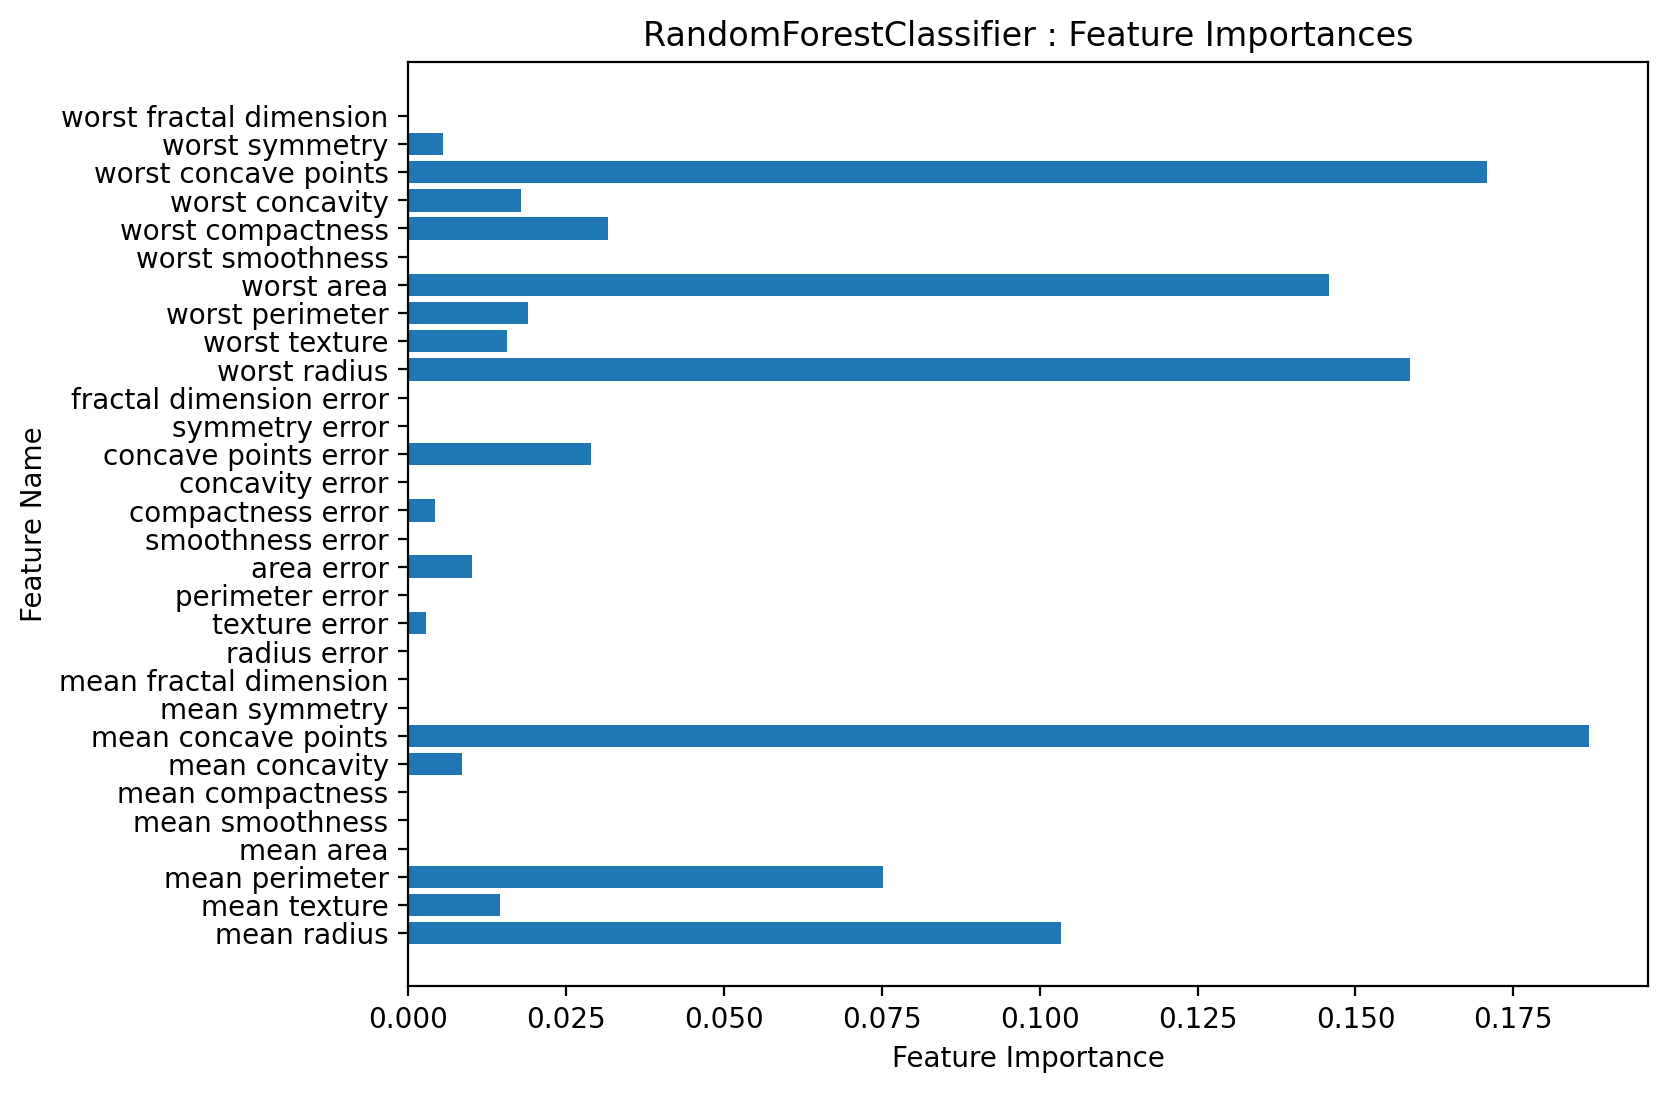

In [57]:
random_forest = GridSearchCV(
    estimator= Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=seed))
    ]
    ),
    param_grid={
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': [None, 2, 3, 4, 5],
        'model__max_leaf_nodes': [None, 2, 3, 4, 5],
        'model__n_estimators': [10, 50, 100]
    },
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True,
).fit(X_train, y_train)
print('Best parameters found: ', random_forest.best_params_)
evaluation_results_rf = evaluate_classifier(random_forest, X_train, y_train, X_test, y_test)
plot_feature_importances(random_forest.best_estimator_.named_steps['model'], features)

<font color = green>

##  Gradient Boosting Decision Trees (GBDT)

</font>



In [58]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
clf = GradientBoostingClassifier(
    random_state=seed,        
    max_depth=3
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 96.503%


Best parameters found:  {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__max_leaf_nodes': None, 'model__n_estimators': 100}


,accuracy,precision,recall,f1_score,roc_auc
train,1.000000,1.000000,1.000000,1.000000,1.000000
test,0.958042,0.966667,0.966667,0.966667,0.997694


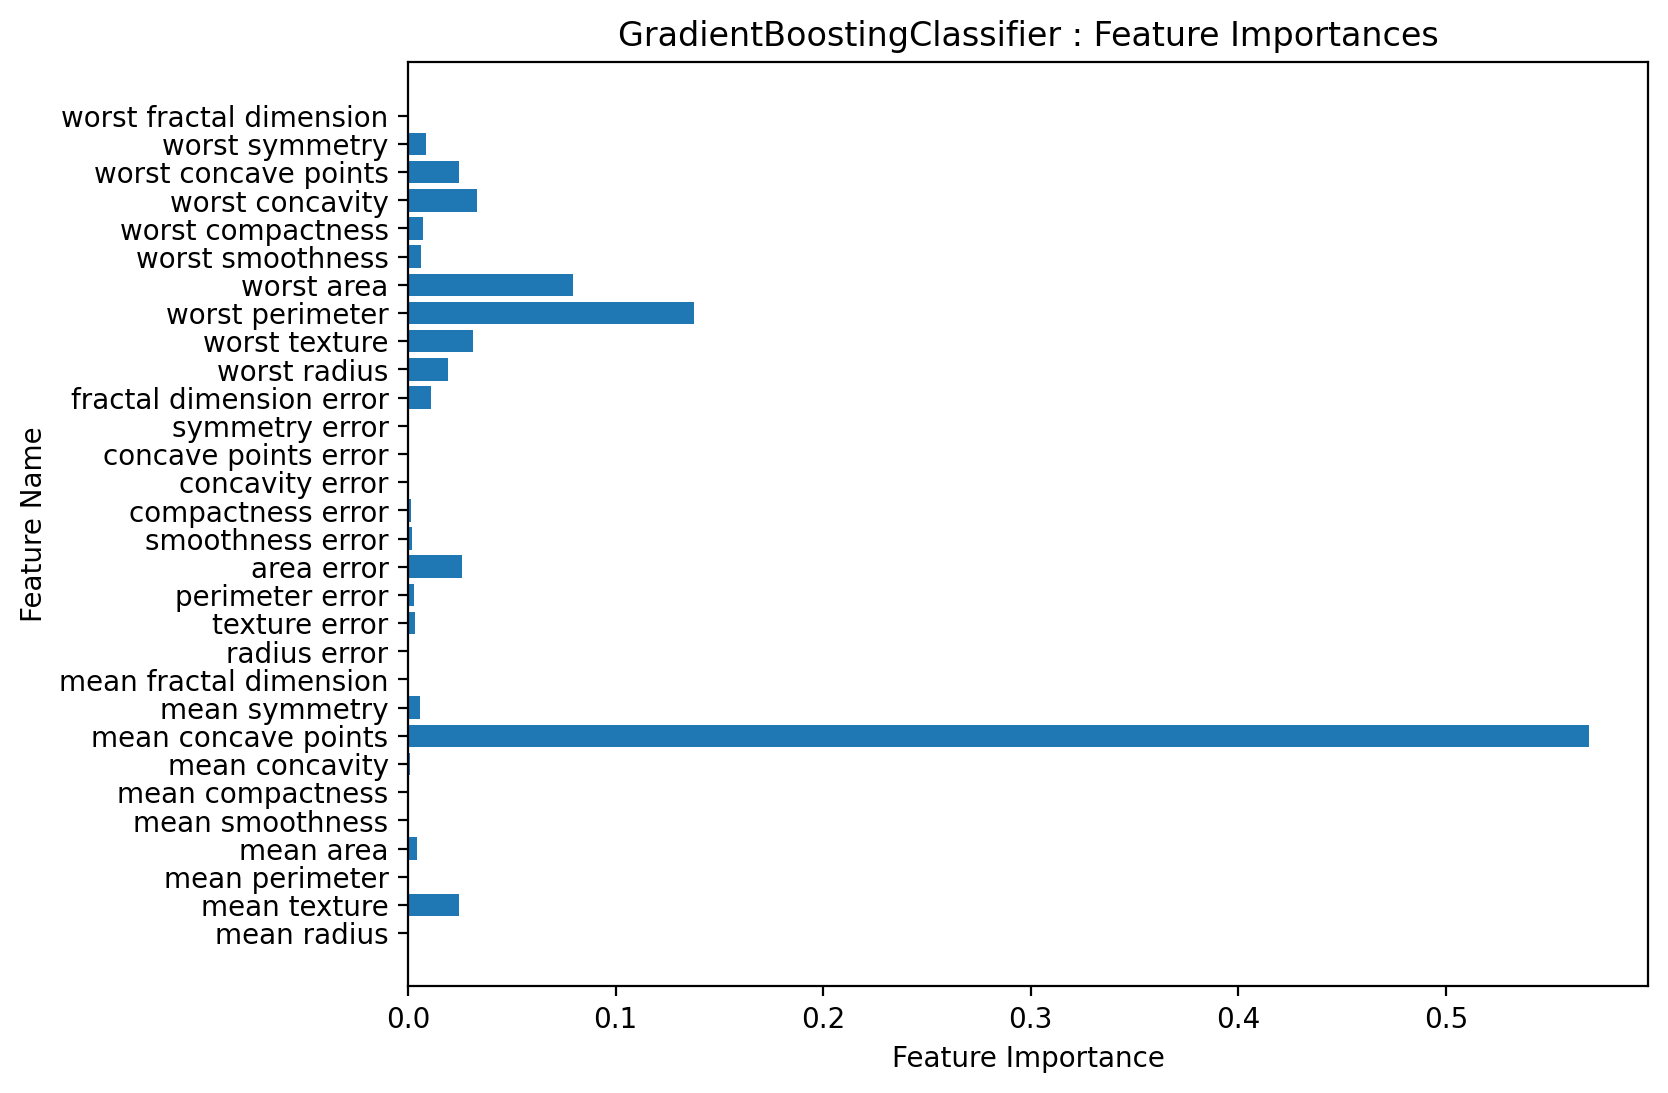

In [59]:
gradient_boosting = GridSearchCV(
    estimator= Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(random_state=seed))
    ]
    ),
    param_grid={
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [None, 2, 3, 4, 5],
        'model__max_leaf_nodes': [None, 2, 3, 4, 5],
        'model__n_estimators': [10, 50, 100]
    },
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True,
).fit(X_train, y_train)
print('Best parameters found: ', gradient_boosting.best_params_)
evaluation_results_gb = evaluate_classifier(gradient_boosting, X_train, y_train, X_test, y_test)
plot_feature_importances(gradient_boosting.best_estimator_.named_steps['model'], features)

<font color = green>

##  XGBoost

</font>



In [60]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
clf = XGBClassifier(
    eval_metric='logloss',
    random_state=seed,        
    max_depth=3
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 98.601%


Best parameters found:  {'model__learning_rate': 1.0, 'model__max_depth': None, 'model__n_estimators': 100, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5}


,accuracy,precision,recall,f1_score,roc_auc
train,1.000000,1.000000,1.000000,1.00000,1.000000
test,0.979021,0.988764,0.977778,0.98324,0.998323


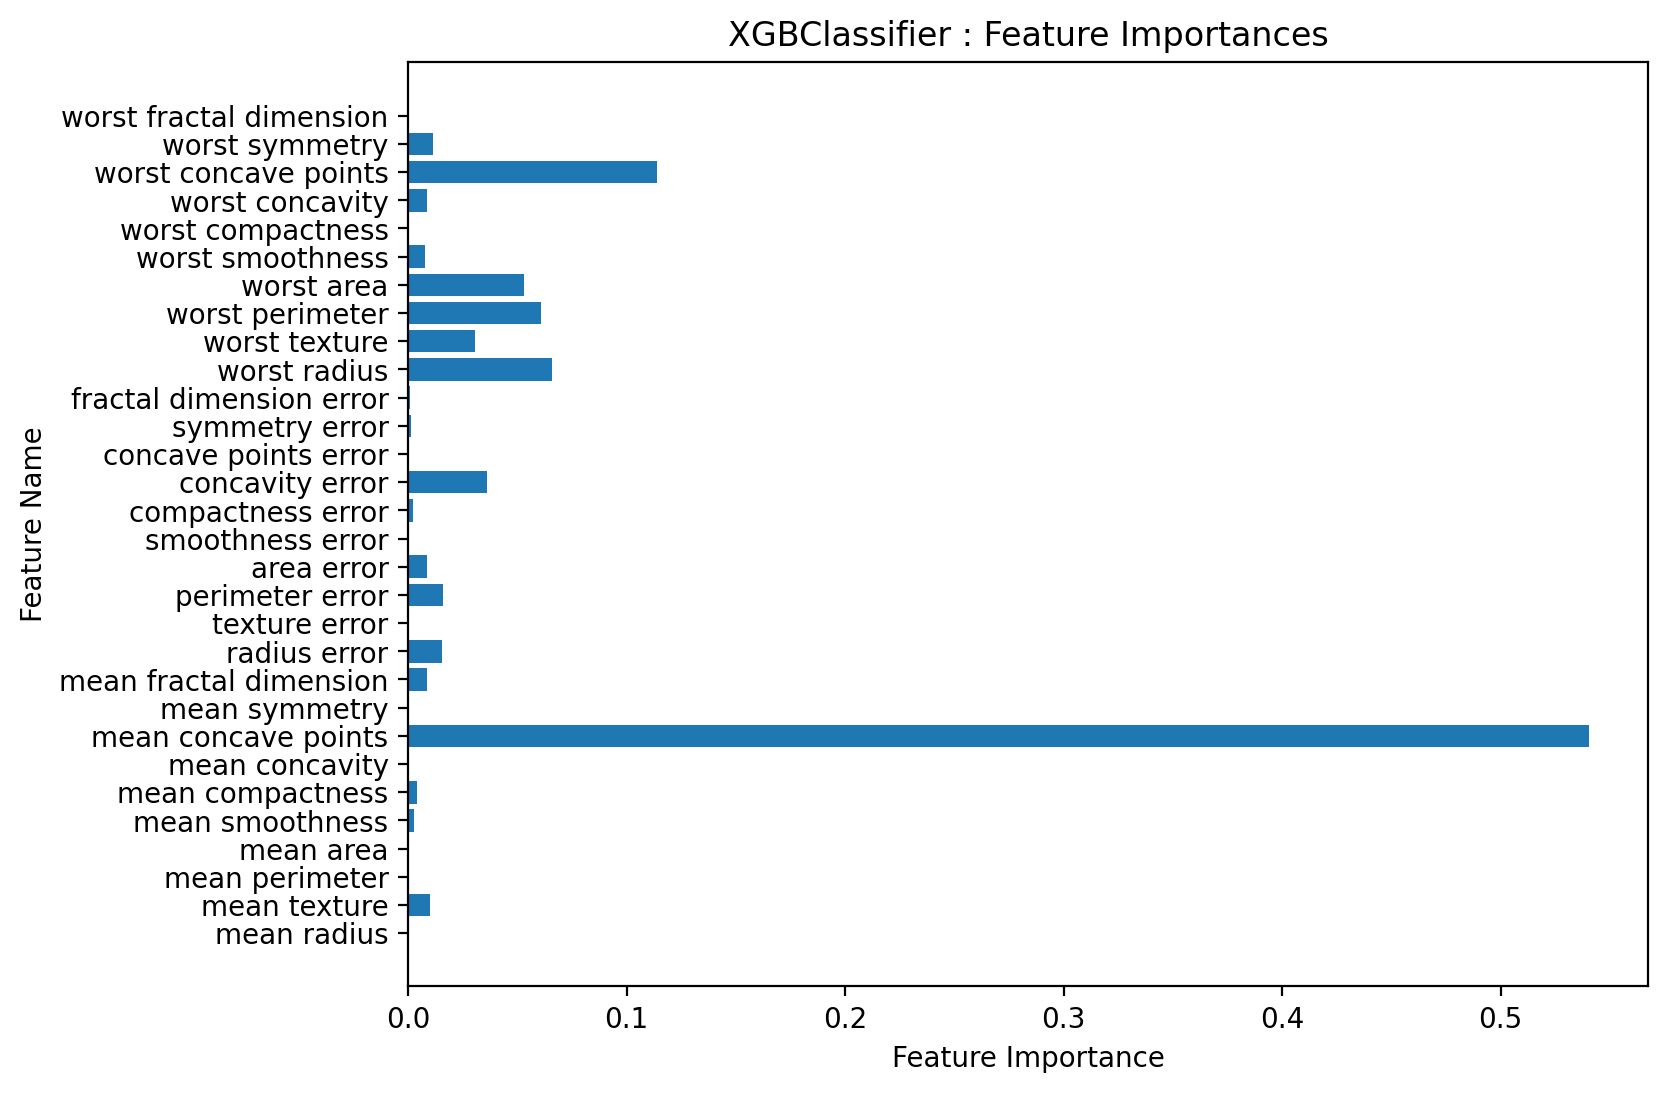

In [61]:
xgb_classifier = GridSearchCV(
    estimator= Pipeline(
    [
        #('scaler', StandardScaler()),
        ('model', XGBClassifier(random_state=seed))
    ]
    ),
    param_grid={
        'model__learning_rate': [0.01, 0.1, 0.2, 0.5, 1.0],
        'model__max_depth': [None, 2, 4, 5],
        'model__n_estimators': [10, 50, 100],
        'model__reg_lambda': [0, 0.1, 1, 5],  # L2 regularization term on weights
        'model__reg_alpha': [0, 0.1, 1, 5]   # L1 regularization term on weights

    },
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True,
).fit(X_train, y_train)
print('Best parameters found: ', xgb_classifier.best_params_)
evaluation_results_xgb = evaluate_classifier(xgb_classifier, X_train, y_train, X_test, y_test)
plot_feature_importances(xgb_classifier.best_estimator_.named_steps['model'], features)

# Additional tasks

### 1) Binary Classification:
    Task: Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

### 2) Regression:
    Task: Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

_____________________________________________________________________________________________________________________________________________________________________________________________________________________

## Assessment Criteria and Requirements

I will evaluate the entire process of working on your project—from the moment you load the dataset to the final result. Your task is to apply all the knowledge you have gained in lectures up to this point.

There is no minimum accuracy threshold: the main focus will be on the quality of implementation. However, if the model’s accuracy is too low, the assignment may not be accepted.

In [62]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Classification:

In [63]:
data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame
df_income.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
32276,63,Private,188914,HS-grad,9,Widowed,Machine-op-inspct,Other-relative,Black,Female,0,0,40,Haiti,<=50K
43235,46,Private,162030,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,43,United-States,<=50K
18846,24,Private,121313,HS-grad,9,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K
8084,21,Private,194096,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,40,United-States,<=50K
18522,54,Private,101017,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K


In [64]:
df_income.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [65]:
df_income.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
count,48842.000000,46043,4.884200e+04,48842,48842.000000,48842,46033,48842,48842,48842,48842.000000,48842.000000,48842.000000,47985,48842
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,37155
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [66]:
missing = df_income.isna().sum() / len(df_income)*100
print('Missing percentage per column:\n', missing)

Missing percentage per column:
 age               0.000000
workclass         5.730724
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
class             0.000000
dtype: float64



Target balance (%):


,percent
class,
<=50K,76.07
>50K,23.93


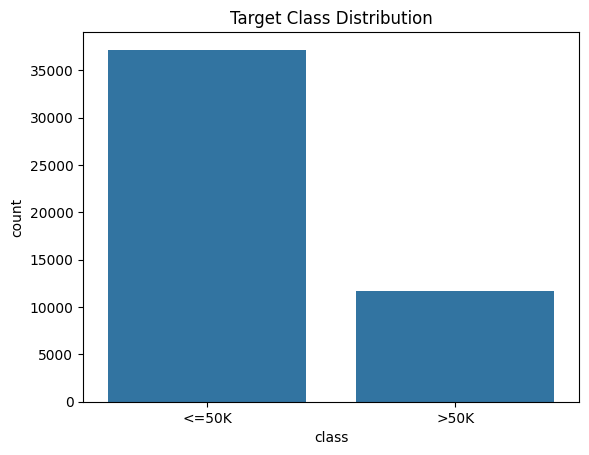


Unique values in categorical features:


,unique_values
native-country,41
education,16
occupation,14
workclass,8
marital-status,7
relationship,6
race,5
sex,2


In [67]:
# dataset overall is clean, but we will check it in more details
import seaborn as sns
target_col = data_class.target.name

eda = df_income.copy().assign(
    **{target_col: lambda df: df[target_col].astype(str).str.strip()}
)# just in case there are spaces in target

print("\nTarget balance (%):")
class_dist = (
    eda[target_col]
    .value_counts(normalize=True)
    .mul(100).round(2)
    .to_frame("percent")
)
display(class_dist)

sns.countplot(data=eda,x=target_col)
plt.title("Target Class Distribution")
plt.show()


print("\nUnique values in categorical features:")
num_cols = eda.select_dtypes(include="number").columns
cat_cols = eda.select_dtypes(exclude="number").columns.drop(target_col, errors="ignore")
display(eda[cat_cols].nunique().nlargest(10).to_frame("unique_values"))

,accuracy,precision,recall,f1_score,roc_auc
train,0.891922,0.825257,0.695608,0.754906,0.949944
test,0.872083,0.777099,0.652635,0.709449,0.927885


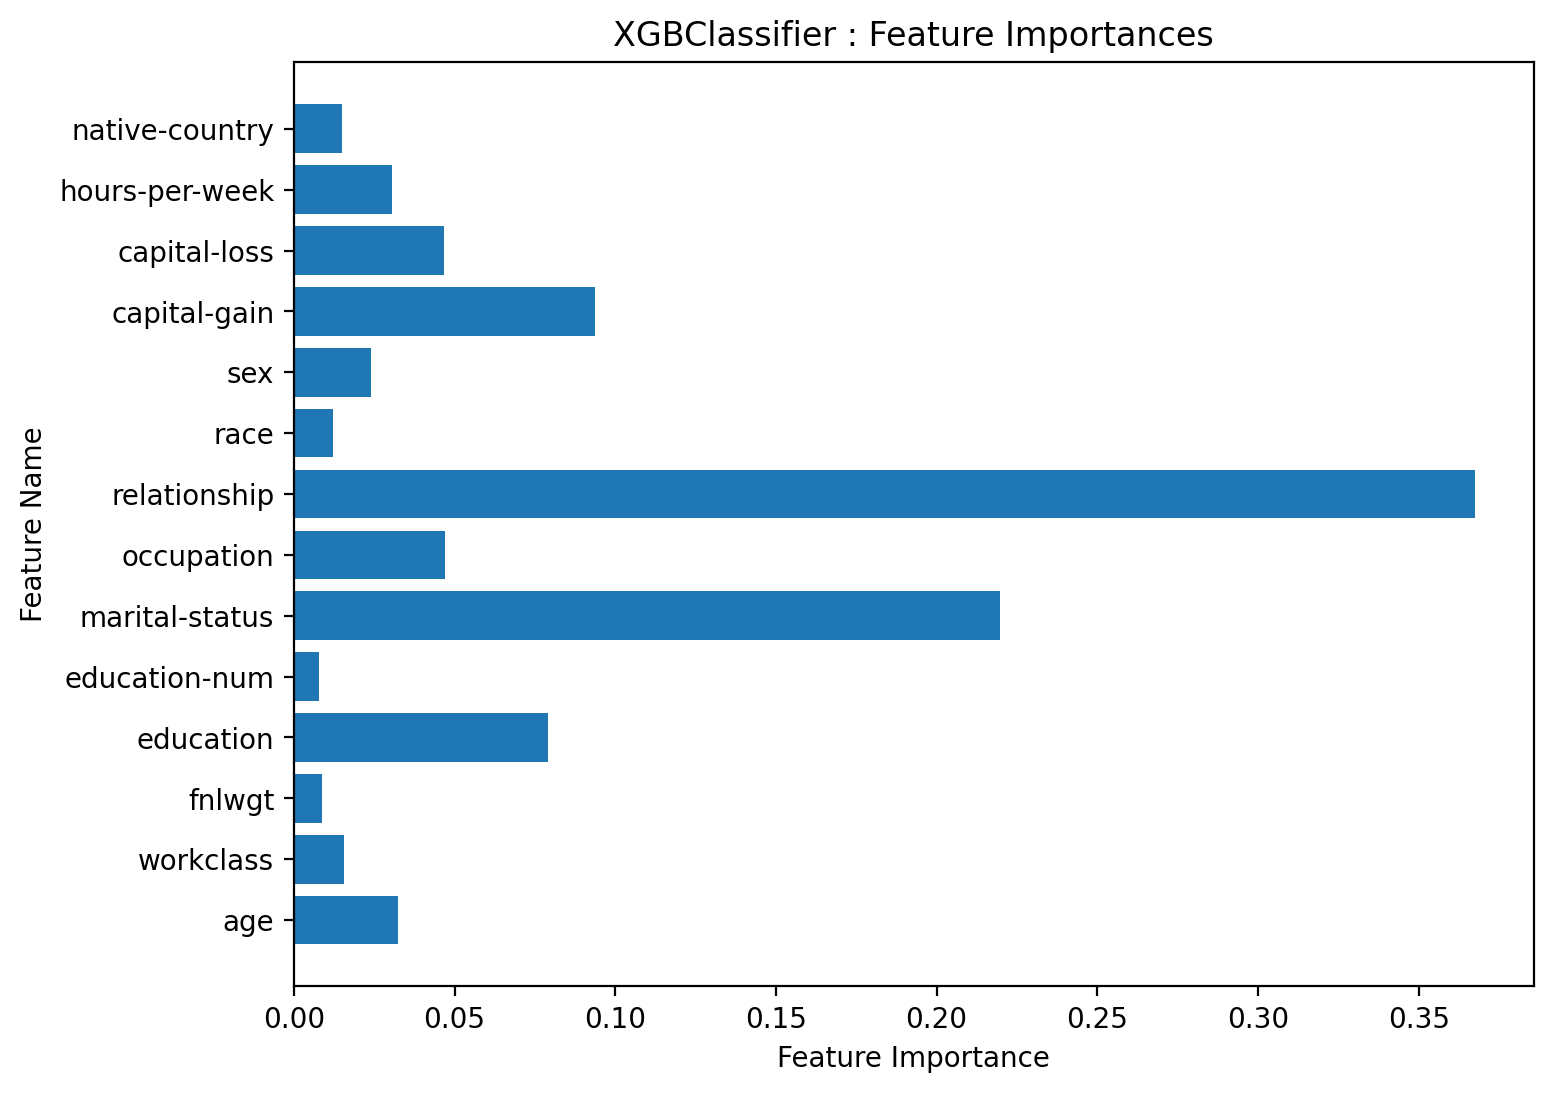

In [68]:
X = (
    eda.drop(columns=[target_col])
    .replace("?", np.nan) # treat "?" as missing value
    .apply(lambda col: col.astype('category') if col.dtype == 'object' else col) # convert object columns to category for XGBoost native handling of categorical features
)# though it will be good practice

y = (eda[target_col] == '>50K').astype(np.int8) #fast binary encoding for target (boolean to int) 

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, stratify=y)

xgb_model = GridSearchCV(
    Pipeline(
    [
        ('xgb', XGBClassifier(
            enable_categorical=True,  # enables native handling of categorical features
            random_state=seed))
    ]),
    param_grid={ #use this param after testing
        'xgb__max_depth': [5],
        'xgb__n_estimators': [200],
        'xgb__learning_rate': [0.1],
        'xgb__reg_lambda': [0.1],  # L2 regularization
        'xgb__reg_alpha': [0.1]    # L1 regularization
    },
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True
).fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_ = evaluate_classifier(xgb_model, X_train, y_train, X_test, y_test)
plot_feature_importances(xgb_model.best_estimator_.named_steps['xgb'], X.columns)

# Regression:

In [69]:
data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [70]:
df_house.isna().sum().sort_values(ascending=False).head(20) / len(df_house) * 100

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
MasVnrType       0.547945
Electrical       0.068493
Id               0.000000
dtype: float64

In [ ]:
df_house.describe(include='all')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [72]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error
# Drop only columns that are genuinely useless (>50% missing or meaningless)
cols_to_drop = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "Id"]
df = df_house.drop(columns=cols_to_drop)
# dont use .dropna() since it will remove too many rows, and XGBoost can handle missing values natively
target_col = data_reg.target.name
X = df.drop(target_col, axis=1)
y = (df[target_col])#

# object to category, leave NaN for XGBoost
X = X.apply(lambda col: col.astype("category") if col.dtype in ["object", "string"] else col)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=seed
)

xgb_reg = GridSearchCV(
    Pipeline(
    [
        ('xgb', XGBRegressor(enable_categorical=True, random_state=seed))
    ]
    ),
    param_grid={
        'xgb__max_depth': [4],
        'xgb__n_estimators': [300],
        'xgb__learning_rate': [0.1],
        'xgb__reg_lambda': [1.0],  # L2 regularization
        'xgb__reg_alpha': [0.5]    # L1 regularization
    },
    scoring='r2',
    n_jobs=1,
    verbose=0,
    refit=True
).fit(X_train, y_train)

y_pred = xgb_reg.predict(X_test)

print(f"MAE  : ${mean_absolute_error(y_test, y_pred):,.0f}")
print(f"MSE  : ${mean_squared_error(y_test, y_pred):,.0f}")
print(f"RMSE : ${root_mean_squared_error(y_test, y_pred):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE  : $14,883
MSE  : $564,510,016
RMSE : $23,759
R²   : 0.9014


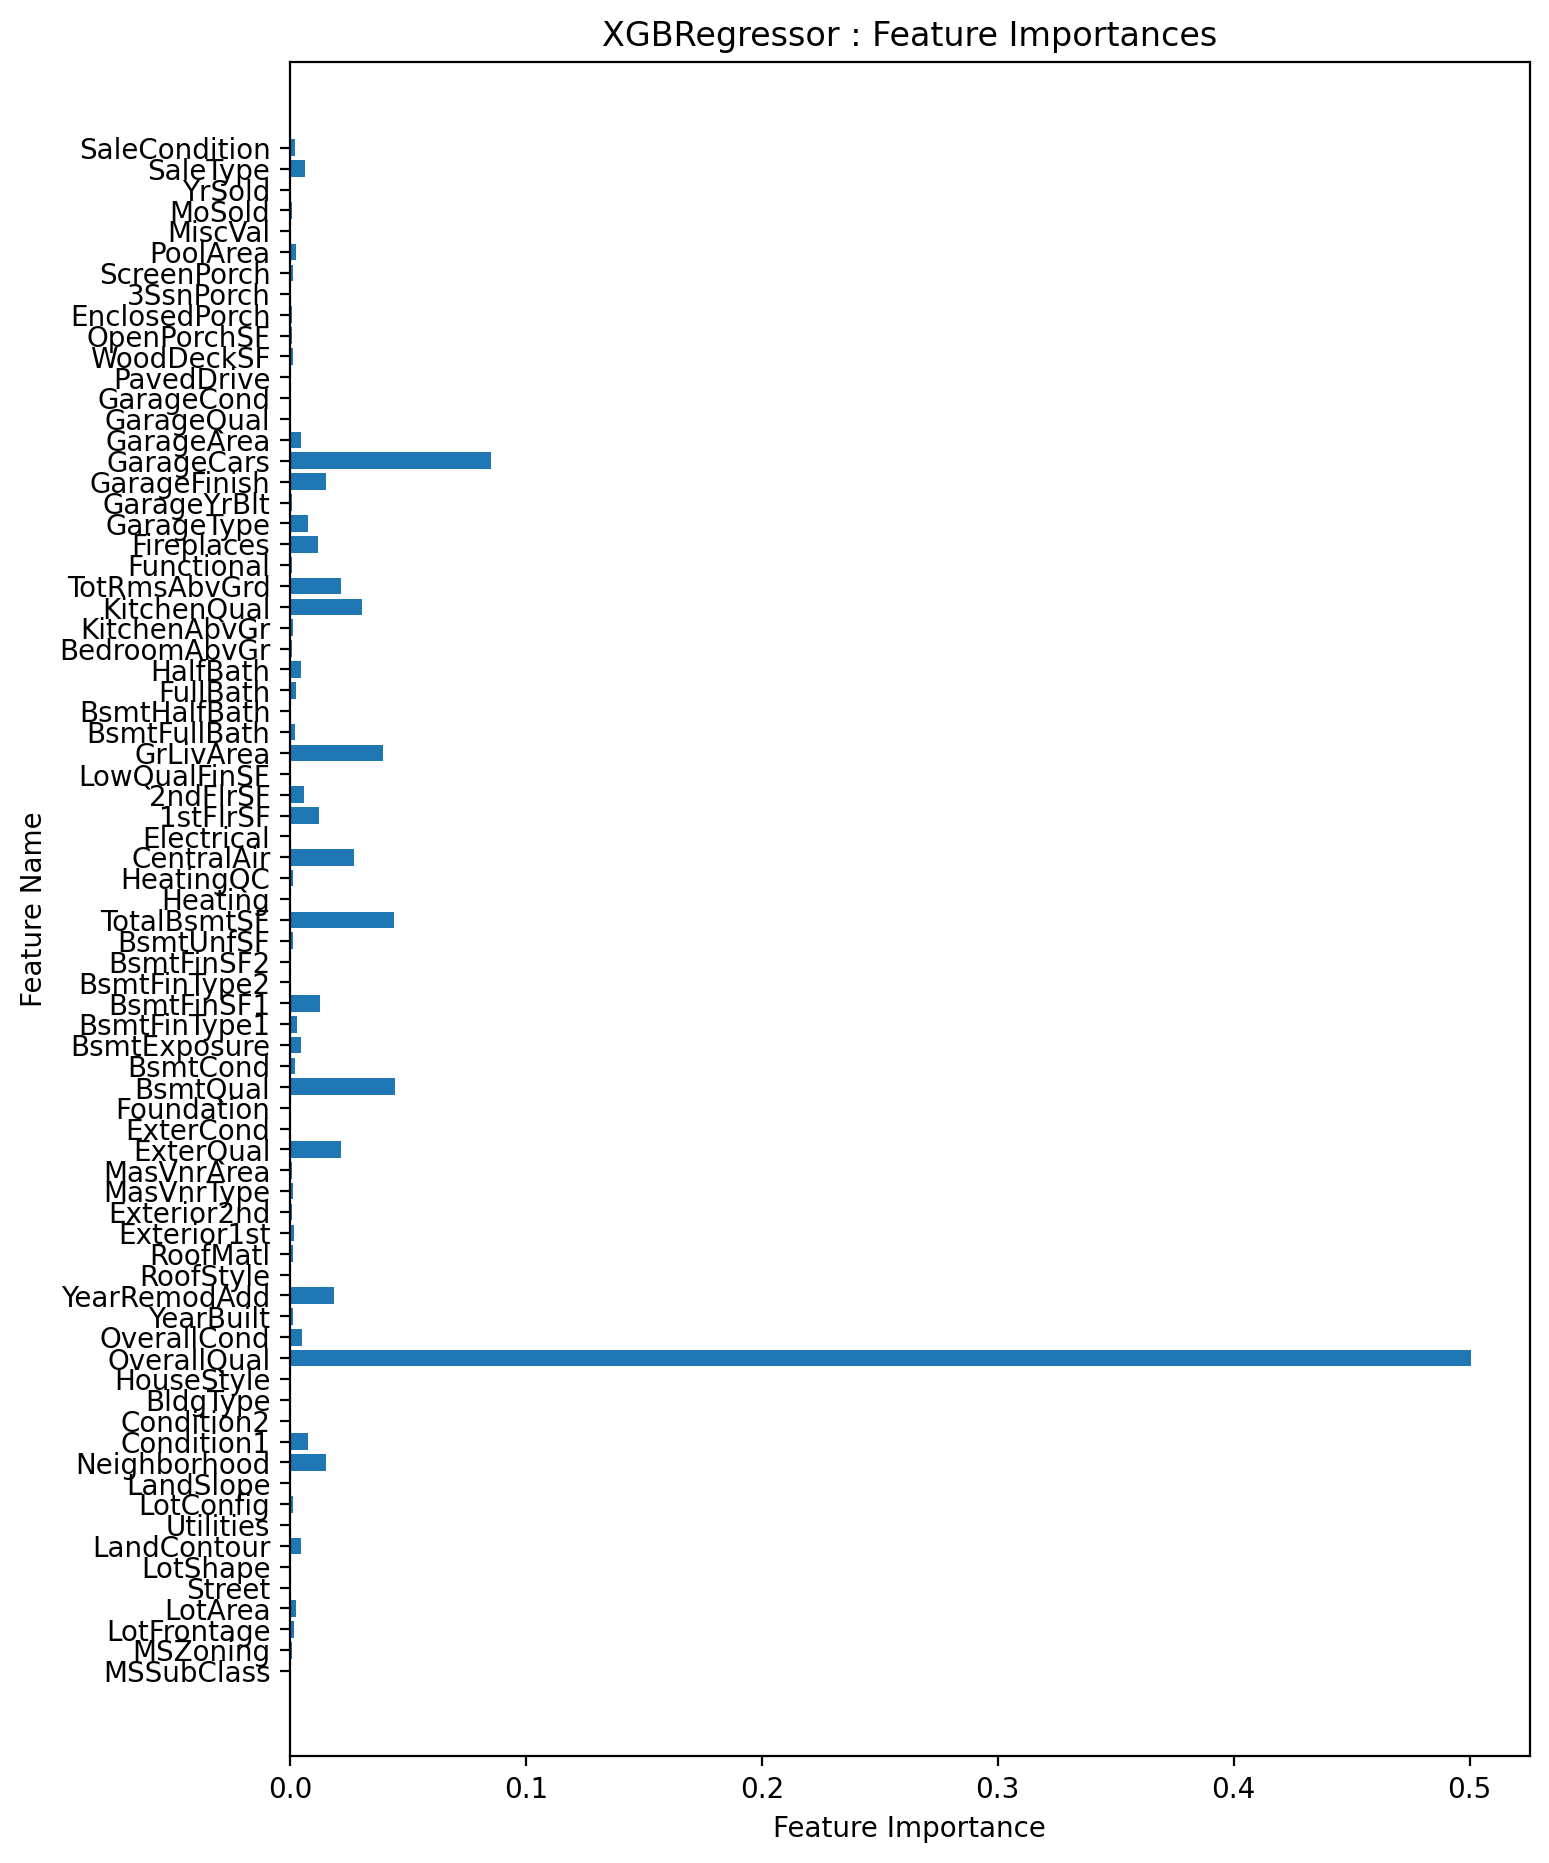

In [73]:
plot_feature_importances(xgb_reg.best_estimator_.named_steps['xgb'], X.columns, figure_size=(8, 11), dpi=200)

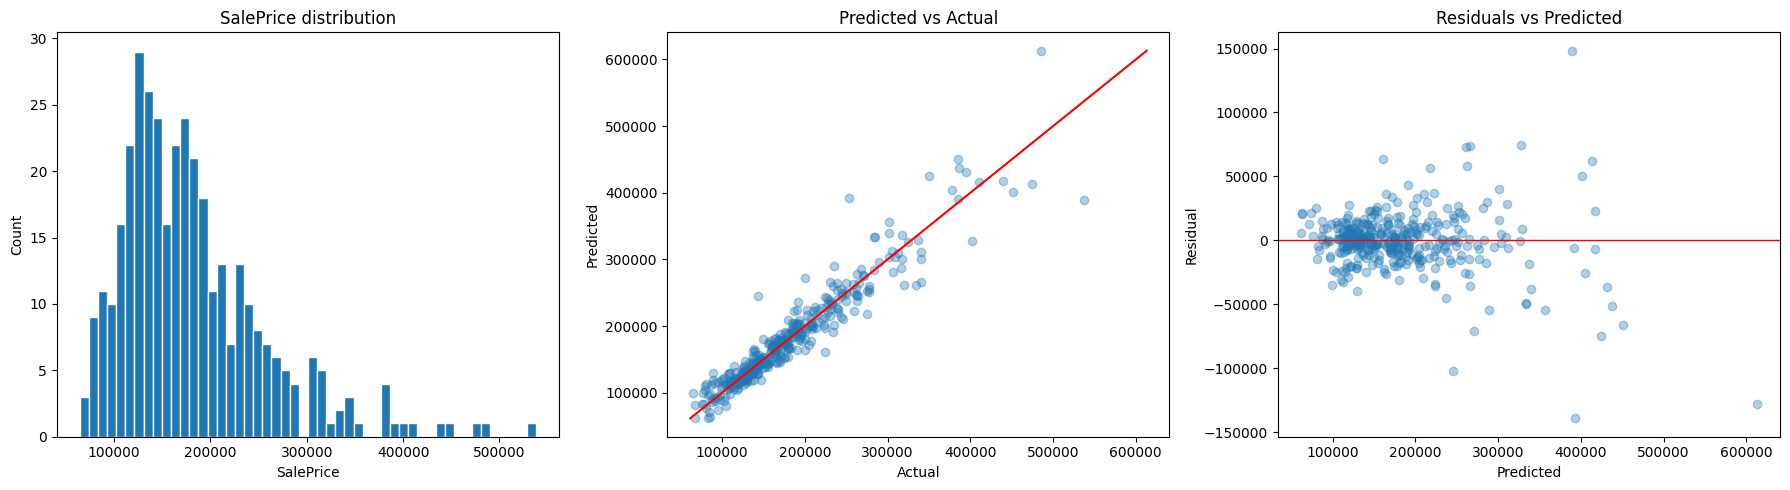

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals = y_test - y_pred

# 1) Target distribution
axes[0].hist(y_test, bins=50,edgecolor='white')
axes[0].set_title("SalePrice distribution")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Count")

# 2) Predicted vs Actual
axes[1].scatter(y_test, y_pred, alpha=0.35)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color="red")
axes[1].set_title("Predicted vs Actual")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

# 3) Residuals vs Predicted
axes[2].scatter(y_pred, residuals, alpha=0.35)
axes[2].axhline(0, color="red", linewidth=1)
axes[2].set_title("Residuals vs Predicted")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()